In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pickle
import re
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier

In [ ]:
import nltk
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [ ]:
!pip install xgboost

In [ ]:
nltk.download('stopwords')
STOPWORDS = set(stopwords.words('english'))
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
import kagglehub
path = kagglehub.dataset_download("ashishkumarak/amazon-shopping-reviews-daily-updated")
print("Path to dataset files:", path)

100%|██████████| 10.1M/10.1M [00:00<00:00, 59.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ashishkumarak/amazon-shopping-reviews-daily-updated/versions/697


In [ ]:
import pandas as pd
import os
files = os.listdir(path)
print(files)
df = pd.read_csv(os.path.join(path, files[0]))
print(f"Dataset shape : {df.shape}")

['amazon_reviews.csv']
Dataset shape : (86098, 8)


In [ ]:
df.head()

,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,f2d6bed7-7a2e-40b8-83f6-e58a075ed43b,Evan C,customer service way worse than it used to be,1,0,32.6.0.100,2026-04-07 09:58:35,32.6.0.100
1,7dd022e5-764e-4063-b506-e1f589ed7924,Hector DeLaFuente,ve there's a reason behind them two Star's not...,2,0,NaN,2026-04-07 08:10:56,NaN
2,12c99916-5902-474c-afcc-2afe80bb541e,Paula,i strongly dislike this app!,1,0,32.7.0.100,2026-04-07 08:10:50,32.7.0.100
3,4290906d-0ae6-41a9-bda6-fa343bdf39e1,richard,I can find what I need for a good value and ve...,5,0,NaN,2026-04-07 07:59:31,NaN
4,8f04e118-9092-4aea-bf23-d4f078c1b9cf,Robert Wingrove,Fox your broken region switching bug!!!,1,0,32.7.0.100,2026-04-07 07:32:06,32.7.0.100


In [ ]:
df.isnull().sum

<bound method DataFrame.sum of        reviewId  userName  content  score  thumbsUpCount  \
0         False     False    False  False          False   
1         False     False    False  False          False   
2         False     False    False  False          False   
3         False     False    False  False          False   
4         False     False    False  False          False   
...         ...       ...      ...    ...            ...   
86093     False     False    False  False          False   
86094     False     False    False  False          False   
86095     False     False    False  False          False   
86096     False     False    False  False          False   
86097     False     False    False  False          False   

       reviewCreatedVersion     at  appVersion  
0                     False  False       False  
1                      True  False        True  
2                     False  False       False  
3                      True  False        True  
4                     False  False       False  
...                     ...    ...         ...  
86093                 False  False       False  
86094                 False  False       False  
86095                 False  False       False  
86096                 False  False       False  
86097                 False  False       False  

[86098 rows x 8 columns]>

reviewCreatedVersion and appVersion containing a large number of null values

In [ ]:
for i, col in enumerate(df.columns):
    print(i, repr(col))

0 'reviewId'
1 'userName'
2 'content'
3 'score'
4 'thumbsUpCount'
5 'reviewCreatedVersion'
6 'at'
7 'appVersion'


In [ ]:
df.isna().sum()

,0
reviewId,0
userName,6
content,6
score,0
thumbsUpCount,0
reviewCreatedVersion,9946
at,0
appVersion,9946


In [ ]:
df[df['content'].isna()]
df[df['userName'].isna()]

,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
10920,227f2f27-4706-466b-b355-bb255c996b1d,NaN,I give any app 1 star that hassles me with a p...,1,0,30.11.0.100,2025-06-19 05:12:03,30.11.0.100
42605,995f40d6-7261-410b-9142-90ca70196cb5,NaN,They wanted my license plate number and what s...,1,0,26.23.0.100,2023-12-17 21:40:51,26.23.0.100
51208,b45b6f8e-6723-4524-bb17-650a42ec61d6,NaN,It seemed to work okay until about a week ago....,1,0,NaN,2021-02-23 18:16:04,NaN
60953,8e981d0c-d33e-46b9-9213-d469a46ada5a,NaN,Search doesn't work. lists things you don't wa...,1,0,22.22.0.100,2024-01-18 19:12:15,22.22.0.100
61378,4ede14fe-f88d-4c2f-806f-45ecf15b9938,NaN,Nightmare service. Try calling support. You'll...,1,0,26.19.2.100,2023-10-02 13:24:23,26.19.2.100
63477,865858aa-df7b-4e66-ac83-535ca266afd4,NaN,Mostly good app but prime day was a lame and p...,4,4,20.20.0.100,2020-10-15 13:06:39,20.20.0.100


In [ ]:
df.dropna(inplace=True)

In [ ]:
print(f"Dataset shape after dropping null values : {df.shape}")

Dataset shape after dropping null values : (76144, 8)


In [ ]:
df['length'] = df['content'].apply(len)

In [ ]:
df.head()

,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion,length
0,f2d6bed7-7a2e-40b8-83f6-e58a075ed43b,Evan C,customer service way worse than it used to be,1,0,32.6.0.100,2026-04-07 09:58:35,32.6.0.100,45
2,12c99916-5902-474c-afcc-2afe80bb541e,Paula,i strongly dislike this app!,1,0,32.7.0.100,2026-04-07 08:10:50,32.7.0.100,28
4,8f04e118-9092-4aea-bf23-d4f078c1b9cf,Robert Wingrove,Fox your broken region switching bug!!!,1,0,32.7.0.100,2026-04-07 07:32:06,32.7.0.100,39
6,098d2c1c-d7be-46b7-b512-d976382d6845,Patricia Thomas,I can't log in..it do say that I have a busine...,3,0,32.7.0.100,2026-04-07 07:17:33,32.7.0.100,364
8,320a698d-e581-4ad7-91a7-135d3130a590,Guillaume Chevalier,"when payment is too big and card bounce, the f...",3,0,32.7.0.100,2026-04-07 06:30:50,32.7.0.100,59


In [ ]:
df['content'] = df['content'].astype(str)
df['length'] = df['content'].apply(lambda x: len(str(x)))
print(f"content column value : {df['content'].iloc[1]}")
print(f"length of review : {len(df['content'].iloc[1])} ")
print(f"length column value : {df['length'].iloc[1]}")

content column value : i strongly dislike this app!
length of review : 28 
length column value : 28


Data Types

In [ ]:
df.dtypes

,0
reviewId,object
userName,object
content,object
score,int64
thumbsUpCount,int64
reviewCreatedVersion,object
at,object
appVersion,object
length,int64


Analyzing 'score' column

In [ ]:
len(df)

76144

In [ ]:
print(f"score value count: \n{df['score'].value_counts()}")

score value count: 
score
1    33942
5    22461
2     8259
3     6421
4     5061
Name: count, dtype: int64


In [ ]:
print(f"Unique values in score column : {df['score'].unique()}")

Unique values in score column : [1 3 5 2 4]


Let's plot the above values in a Bar Graph (for score)

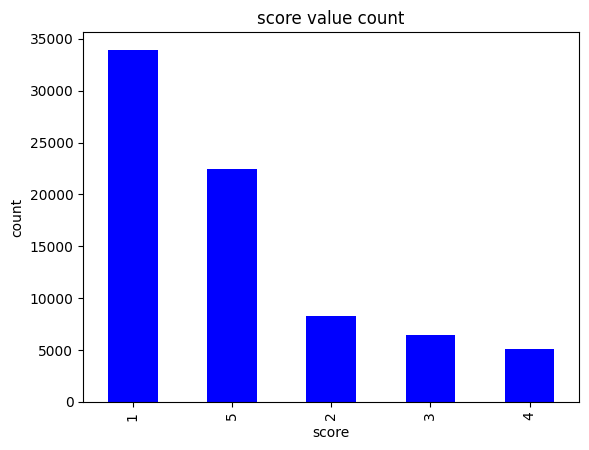

In [ ]:
df['score'].value_counts().plot.bar(color='blue')
plt.title("score value count")
plt.xlabel("score")
plt.ylabel("count")
plt.show()

Pie Chart

([<matplotlib.patches.Wedge at 0x79fa8bd2bc80>,
 [Text(0.18653187825850237, 1.0840691206714428, '1'),
  Text(-0.9165281750316633, -0.6082566106283835, '3'),
  Text(0.306718083431869, -1.0563730483573885, '5'),
  Text(0.8535702178628836, -0.6938428375197873, '2'),
  Text(1.0761063006077394, -0.22802462540770815, '4')],
 [Text(0.10174466086827401, 0.5913104294571506, '45%'),
  Text(-0.4999244591081799, -0.33177633307002735, '29%'),
  Text(0.16730077278101943, -0.5762034809222119, '11%'),
  Text(0.4655837551979364, -0.37845972955624757, '8%'),
  Text(0.5869670730587669, -0.12437706840420443, '7%')])

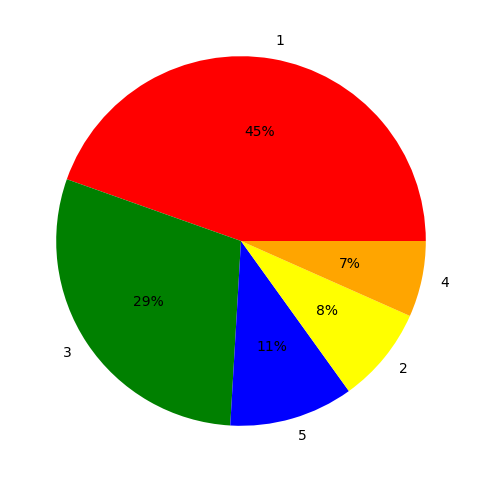

In [ ]:
fig = plt.figure(figsize=(6,6))
colors = ('red','green','blue','yellow','orange')
plt.pie(df['score'].value_counts(),
labels=df['score'].unique(),
colors=colors,
autopct='%.0f%%')

Since our feedback in the table is named as content.
Let's analyze count

In [ ]:
print(f"content value count: \n{df['content'].value_counts()}")

content value count: 
content
good                                                                                                                                                                                                                                                                                                                                       277
Good                                                                                                                                                                                                                                                                                                                                       226
Great                                                                                                                                                                                                                                                                                                       

Bar Graph (for content/feedback)

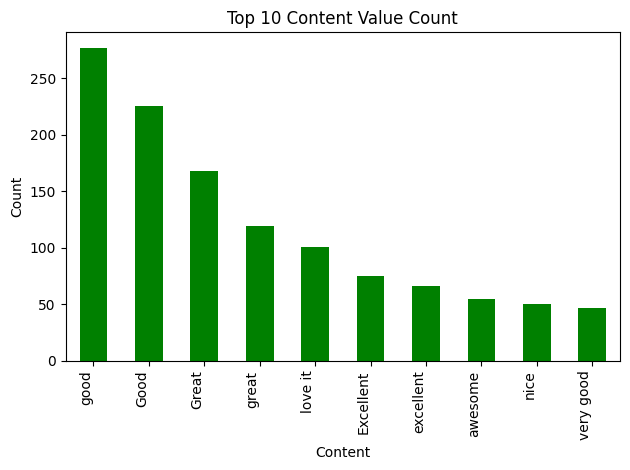

In [ ]:
import matplotlib as mpl
top_content_counts = df['content'].value_counts().head(10)
mpl.rcParams['text.usetex'] = False
mpl.rcParams['mathtext.default'] = 'regular'
top_content_counts.plot.bar(color='green')
plt.title("Top 10 Content Value Count")
plt.xlabel("Content")
plt.ylabel("Count")
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

Pie Chart

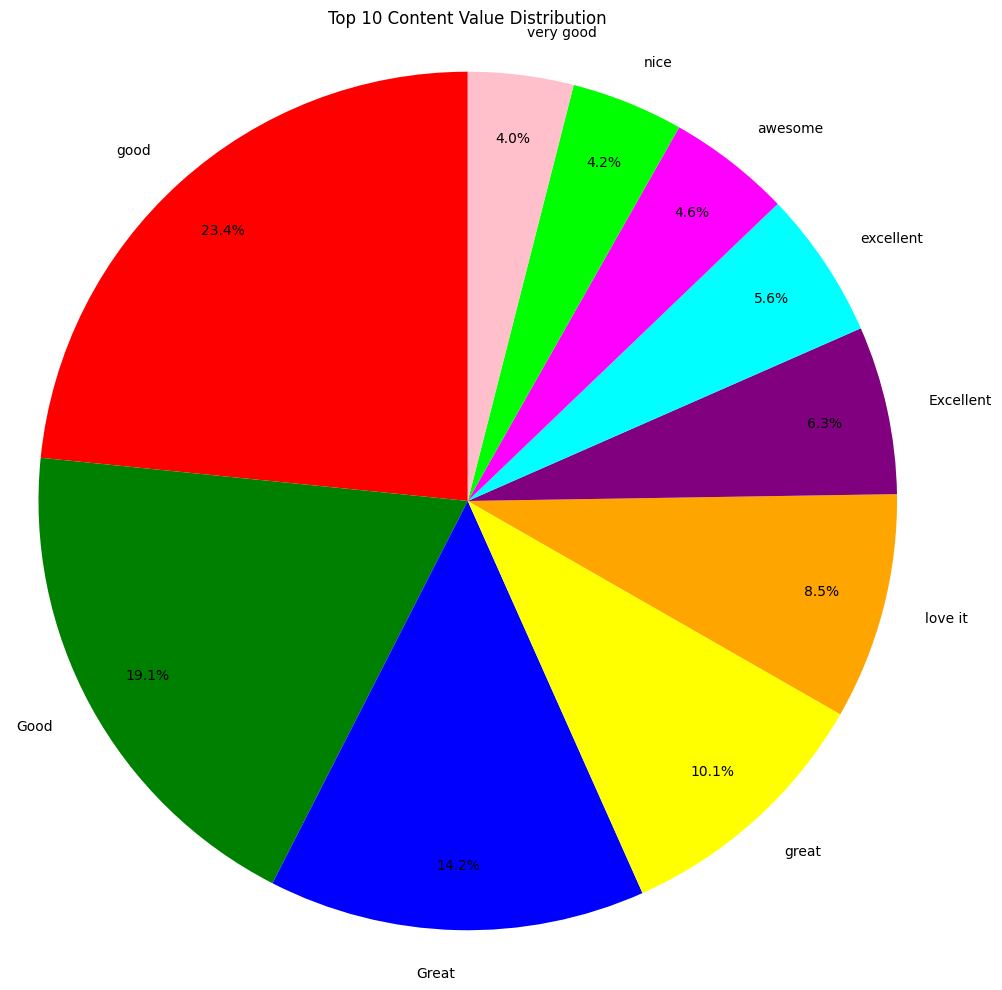

In [ ]:
import matplotlib as mpl
top_content_counts = df['content'].value_counts().head(10)
pie_labels = top_content_counts.index.tolist()
pie_values = top_content_counts.values
mpl.rcParams['text.usetex'] = False
mpl.rcParams['mathtext.default'] = 'regular'
fig = plt.figure(figsize=(10, 10))
colors = ['red', 'green', 'blue', 'yellow', 'orange', 'purple', 'cyan', 'magenta', 'lime', 'pink']
plt.pie(pie_values,
        labels=pie_labels,
        colors=colors[:len(pie_values)],
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=0.85
       )
plt.title("Top 10 Content Value Distribution")
plt.axis('equal')
plt.tight_layout()
plt.show()

Let's see the 'score' values for different values of 'content'

In [ ]:
print("Examining score distribution for the top 5 most frequent content entries:")
top_5_content = df['content'].value_counts().head(5)
for content_text, count in top_5_content.items():
    print(f"--- Content: '{content_text}' (appears {count} times) ---")
    score_distribution = df[df['content'] == content_text]['score'].value_counts().sort_index()
    if not score_distribution.empty:
        print(score_distribution)
    else:
        print("No scores found for this content.")
    print()

Examining score distribution for the top 5 most frequent content entries:
--- Content: 'good' (appears 277 times) ---
score
1      4
2      5
3     12
4     27
5    229
Name: count, dtype: int64

--- Content: 'Good' (appears 226 times) ---
score
1      3
2      4
3     11
4     30
5    178
Name: count, dtype: int64

--- Content: 'Great' (appears 168 times) ---
score
1      1
3      3
4     16
5    148
Name: count, dtype: int64

--- Content: 'great' (appears 119 times) ---
score
1      1
3      2
4      3
5    113
Name: count, dtype: int64

--- Content: 'love it' (appears 101 times) ---
score
4     8
5    93
Name: count, dtype: int64



Calculating mean of score and content

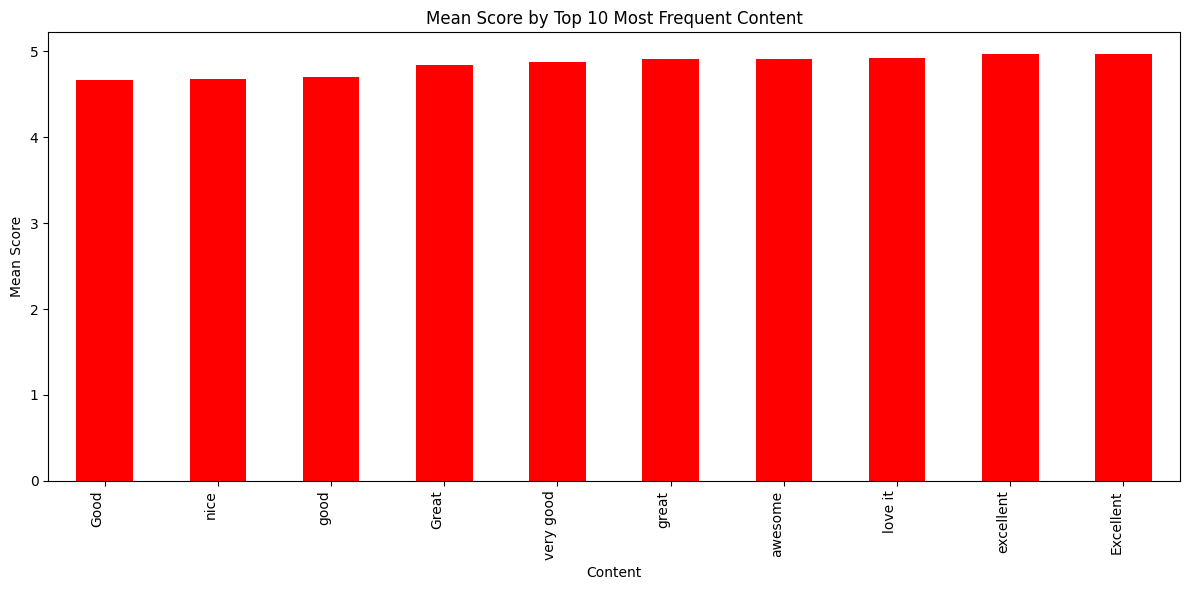

In [ ]:
import matplotlib as mpl
top_10_content = df['content'].value_counts().head(10).index
df_top_content = df[df['content'].isin(top_10_content)]
mean_scores_top_content = df_top_content.groupby('content')['score'].mean().sort_values()
mpl.rcParams['text.usetex'] = False
mpl.rcParams['mathtext.default'] = 'regular'
mean_scores_top_content.plot.bar(color = 'red', figsize = (12, 6))
plt.title('Mean Score by Top 10 Most Frequent Content')
plt.xlabel('Content')
plt.ylabel('Mean Score')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

Analyzing 'reviewId'

In [ ]:
df['length'].describe()

,length
count,76144.000000
mean,184.585824
std,144.495588
min,1.000000
25%,75.000000
50%,143.000000
75%,269.000000
max,1594.000000


Length analysis for full dataset

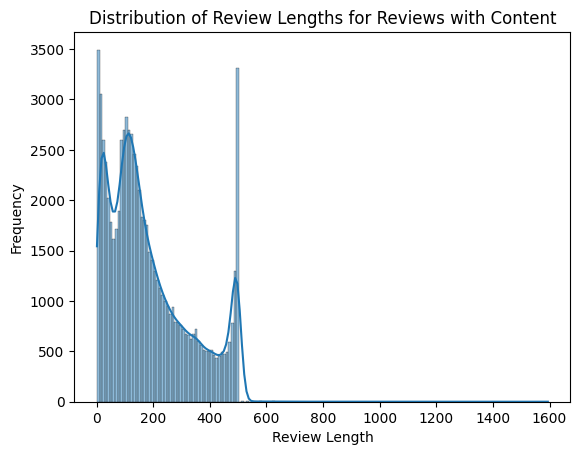

In [ ]:
sns.histplot(df['length'], kde=True)
plt.title('Distribution of Review Lengths for Reviews with Content')
plt.xlabel('Review Length')
plt.ylabel('Frequency')
plt.show()

Length wise mean rating

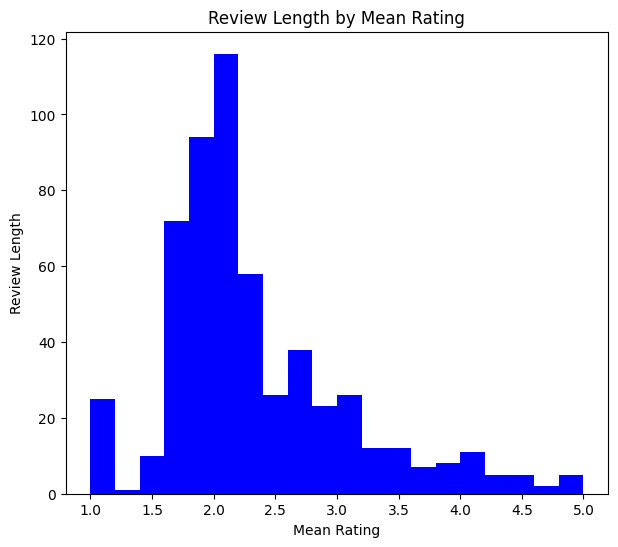

In [ ]:
df.groupby('length')['score'].mean().plot.hist(color='blue',figsize = (7,6), bins=20)
plt.title('Review Length by Mean Rating')
plt.xlabel('Mean Rating')
plt.ylabel('Review Length')
plt.show()

**Count Vectorizer**

In [ ]:
cv = CountVectorizer(stop_words='english')
words = cv.fit_transform(df['content'])

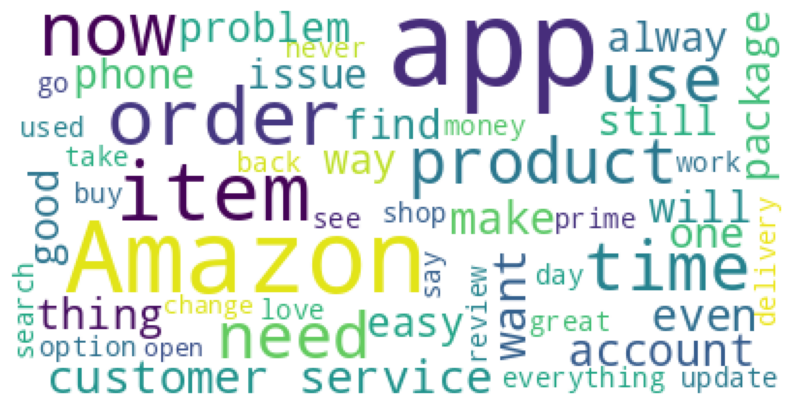

In [ ]:
content = " ".join([content for content in df['content']])
wc = WordCloud(background_color='white', max_words=50)
plt.figure(figsize=(10,10))
plt.imshow(wc.generate(content))
plt.axis('off')
plt.show()

**Preprocessing and Cleaning**

To build the corpus from the 'content' we perfrom the following-

1. Replace any non alphabet characters with a space
2. Convert to lower case and split into words
3. Iterate over the individual words and if it is not a stopword then add the stemmed form of the word to the corpus

In [ ]:
corpus = []
stemmer = PorterStemmer()
for i in range(len(df)):
    text = re.sub('[^a-zA-Z]', ' ', df['content'].iloc[i])
    text = text.lower().split()
    text = [stemmer.stem(word) for word in text if word not in STOPWORDS]
    text = ' '.join(text)
    corpus.append(text)

**TF - IDF**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(corpus).toarray()
y = df['score']

**Feature Extraction**

In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9
)
tfidf.fit(corpus)

TfidfVectorizer(max_df=0.9, max_features=5000, min_df=2, ngram_range=(1, 2))

**Splitting data into train and test set with 30% data with testing.**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Shape of X_train : {X_train.shape}")
print(f"Shape of y_train : {y_train.shape}")
print(f"Shape of X_test : {X_test.shape}")
print(f"Shape of y_test : {y_test.shape}")

Shape of X_train : (53300, 5000)
Shape of y_train : (53300,)
Shape of X_test : (22844, 5000)
Shape of y_test : (22844,)


**Confusion Matrix**

In [ ]:
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)
y_preds = model_dt.predict(X_test)
cm = confusion_matrix(y_test, y_preds)
print(cm)

[[7033 1201  728  300  861]
 [1455  339  304  145  234]
 [1004  288  235  169  293]
 [ 448  145  155  145  624]
 [ 754  185  206  384 5209]]


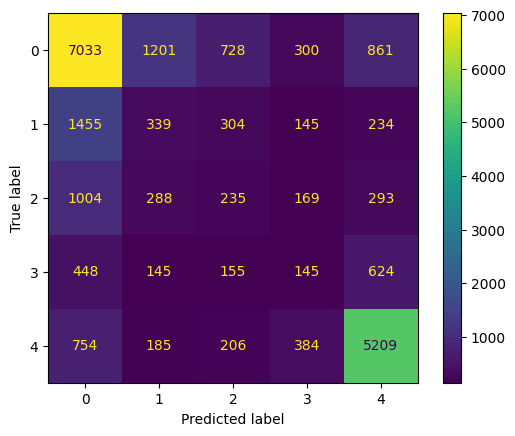

In [ ]:
cm = confusion_matrix(y_test, y_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

**Lemmatization and Tokenization**

In [ ]:
nltk.download('punkt')
nltk.download('wordnet')
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
def simple_preprocess(text):
    words = word_tokenize(text)
    words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(words)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
nltk.download('punkt_tab')
df['cleaned_text'] = df['content'].apply(simple_preprocess)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
print(df['cleaned_text'].iloc[0])

customer service way worse than it used to be


In [ ]:
print(df[['content', 'cleaned_text']].head())

                                             content  \
0      customer service way worse than it used to be   
2                       i strongly dislike this app!   
4            Fox your broken region switching bug!!!   
6  I can't log in..it do say that I have a busine...   
8  when payment is too big and card bounce, the f...   

                                        cleaned_text  
0      customer service way worse than it used to be  
2                      i strongly dislike this app !  
4         Fox your broken region switching bug ! ! !  
6  I ca n't log in .. it do say that I have a bus...  
8  when payment is too big and card bounce , the ...  


**Random Forest**

In [ ]:
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
print("Training Accuracy :", model_rf.score(X_train, y_train))
print("Testing Accuracy :", model_rf.score(X_test, y_test))

Training Accuracy : 0.9828517823639775
Testing Accuracy : 0.6788215724041323


**Decision Tree Classifier**

In [ ]:
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)
y_preds = model_dt.predict(X_test)

In [ ]:
print("Training Accuracy :", model_dt.score(X_train, y_train))
print("Testing Accuracy :", model_dt.score(X_test, y_test))

Training Accuracy : 0.9828517823639775
Testing Accuracy : 0.5673699877429522


**Logistic Regression**

In [ ]:
model_ds = LogisticRegression(max_iter=1000,n_jobs=-1)
model_ds.fit(X_train, y_train)
y_pred = model_ds.predict(X_test)

In [ ]:
print("Training Accuracy :", model_ds.score(X_train, y_train))
print("Testing Accuracy :", model_ds.score(X_test, y_test))

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Step 1: Convert text → numbers
tfidf = TfidfVectorizer(max_features=7000)
X_train_vec = tfidf.fit_transform(X_train_text)
X_test_vec = tfidf.transform(X_test_text)

# Step 2: Train model
model = LogisticRegression(max_iter=5000)
model.fit(X_train_vec, y_train)

# Step 3: Evaluate
print("Train:", model.score(X_train_vec, y_train))
print("Test :", model.score(X_test_vec, y_test))

**Multinomial Naive Bayes**

In [ ]:
model_sf = MultinomialNB()
model_sf.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
print("Training Accuracy :", model_sf.score(X_train, y_train))
print("Testing Accuracy :", model_sf.score(X_test, y_test))

**Linear SVM**

In [ ]:
model_cv = LinearSVC()
model_cv.fit(X_train, y_train)
y_pred = model_cv.predict(X_test)

In [ ]:
print("Training Accuracy :", model_cv.score(X_train, y_train))
print("Testing Accuracy :", model_cv.score(X_test, y_test))

In [ ]:
with open("logistic_model.pkl", "wb") as f:
    pickle.dump(model_ds, f)

In [ ]:
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)